# Covid analysis 

Notebook zawiera wstępne przetwarzanie, czyszczenie i wizualizację danych COVID-19. Celem jest przygotowanie danych do dalszych analiz i prognoz.

#### Import bibliotek

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


#### Wczytanie i przegląd danych

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('data/covid-data.csv')

In [7]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,tests_units,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


## Czyszczenie i wstępne przetwarzanie danych

Konwersja kolumny date jako typ daty oraz identyfikacja i usunięcie kolumn z dużym odsetkiem brakujących wartości. Usuwane kolumny są nadmiarowe, nie są aż tak znaczące w analizie lub mocno niekompletne.

In [8]:
df.shape

(429435, 67)

In [9]:
df.dtypes

iso_code                                       object
continent                                      object
location                                       object
date                                           object
total_cases                                   float64
new_cases                                     float64
new_cases_smoothed                            float64
total_deaths                                  float64
new_deaths                                    float64
new_deaths_smoothed                           float64
total_cases_per_million                       float64
new_cases_per_million                         float64
new_cases_smoothed_per_million                float64
total_deaths_per_million                      float64
new_deaths_per_million                        float64
new_deaths_smoothed_per_million               float64
reproduction_rate                             float64
icu_patients                                  float64
icu_patients_per_million    

In [10]:
print('Przed:', df['date'].dtype)
df['date'] = pd.to_datetime(df['date'])
print('Po:', df['date'].dtype)

Przed: object
Po: datetime64[ns]


In [11]:
print(df.isnull().sum().to_string())

iso_code                                           0
continent                                      26525
location                                           0
date                                               0
total_cases                                    17631
new_cases                                      19276
new_cases_smoothed                             20506
total_deaths                                   17631
new_deaths                                     18827
new_deaths_smoothed                            20057
total_cases_per_million                        17631
new_cases_per_million                          19276
new_cases_smoothed_per_million                 20506
total_deaths_per_million                       17631
new_deaths_per_million                         18827
new_deaths_smoothed_per_million                20057
reproduction_rate                             244618
icu_patients                                  390319
icu_patients_per_million                      

In [12]:
cols_to_drop = [
    'icu_patients', 'icu_patients_per_million',
    'hosp_patients', 'hosp_patients_per_million',
    'weekly_icu_admissions', 'weekly_icu_admissions_per_million',
    'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million',
    'total_tests', 'new_tests',
    'total_tests_per_thousand', 'new_tests_per_thousand',
    'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
    'tests_units', 'total_boosters', 'total_boosters_per_hundred',
    'new_vaccinations_smoothed_per_million',
    'new_people_vaccinated_smoothed',
    'new_people_vaccinated_smoothed_per_hundred',
    'excess_mortality', 'excess_mortality_cumulative',
    'excess_mortality_cumulative_absolute',
    'excess_mortality_cumulative_per_million',
    'handwashing_facilities', 'extreme_poverty',
    'female_smokers', 'male_smokers'
]

df = df.drop(columns=cols_to_drop)

Ponowne sprawdzenie braków po usunięciu kolumn

In [13]:
print(df.isnull().sum().to_string())

iso_code                                    0
continent                               26525
location                                    0
date                                        0
total_cases                             17631
new_cases                               19276
new_cases_smoothed                      20506
total_deaths                            17631
new_deaths                              18827
new_deaths_smoothed                     20057
total_cases_per_million                 17631
new_cases_per_million                   19276
new_cases_smoothed_per_million          20506
total_deaths_per_million                17631
new_deaths_per_million                  18827
new_deaths_smoothed_per_million         20057
reproduction_rate                      244618
positive_rate                          333508
tests_per_case                         335087
total_vaccinations                     344018
people_vaccinated                      348303
people_fully_vaccinated           

### Usunięcie danych niekrajowych

Niektóre rekordy w zbiorze nie odpowiadają poszczególnym krajom (np. regiony, kontynenty, organizacje).

In [14]:
df.loc[df['continent'].isna(), 'location'].unique()

array(['Africa', 'Asia', 'Europe', 'European Union (27)',
       'High-income countries', 'Low-income countries',
       'Lower-middle-income countries', 'North America', 'Oceania',
       'South America', 'Upper-middle-income countries', 'World'],
      dtype=object)

In [15]:
non_countries = df[df['continent'].isna()]['location'].unique()
df = df[~df['location'].isin(non_countries)].reset_index(drop=True)

In [16]:
# print(df.isnull().sum().to_string())

### Sprawdzenie kolumn z wartościami ujemnymi

In [17]:
num_df = df.select_dtypes(include='number')
num_df.columns[(num_df < 0).any()]

Index(['reproduction_rate'], dtype='object')

In [18]:
(df['reproduction_rate'] < 0).mean() * 100

np.float64(0.04417860068005262)

### Interpolacja liniowa zmiennych zmieniających się w czasie

Przed interpolacją dane są sortowane według location i date. Dodatkowo stosowane jest ffill() i bfill() dla pełnego uzupełnienia braków.

In [19]:
df = df.sort_values(["location", "date"])
interpolate_cols = [
    'total_cases', 'new_cases', 'new_cases_smoothed',
    'total_deaths', 'new_deaths', 'new_deaths_smoothed',
    'total_cases_per_million', 'new_cases_per_million',
    'new_cases_smoothed_per_million', 'total_deaths_per_million',
    'new_deaths_per_million', 'new_deaths_smoothed_per_million',
    'reproduction_rate', 'positive_rate', 'tests_per_case',
    'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated',
    'new_vaccinations', 'new_vaccinations_smoothed',
    'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred', 'stringency_index'
]

df = df.sort_values(["location", "date"])
df[interpolate_cols] = df.groupby("location")[interpolate_cols].transform(lambda group: group.interpolate(method="linear").ffill().bfill())

In [20]:
print(df[interpolate_cols].isnull().sum().to_string())

total_cases                              9723
new_cases                                9723
new_cases_smoothed                       9723
total_deaths                             9723
new_deaths                               9723
new_deaths_smoothed                      9723
total_cases_per_million                  9723
new_cases_per_million                    9723
new_cases_smoothed_per_million           9723
total_deaths_per_million                 9723
new_deaths_per_million                   9723
new_deaths_smoothed_per_million          9723
reproduction_rate                       77403
positive_rate                          107168
tests_per_case                         108842
total_vaccinations                      31807
people_vaccinated                       31807
people_fully_vaccinated                 35155
new_vaccinations                       107137
new_vaccinations_smoothed               31807
total_vaccinations_per_hundred          31807
people_vaccinated_per_hundred     

### Uzupełnianie zmiennych statycznych

Zmienne stałe (demograficzne, ekonomiczne i zdrowotne), niezmienne w czasie, uzupełniane są medianą z całego zbioru.

In [21]:
cols_static = [
    'population_density', 'median_age', 'aged_65_older', 'aged_70_older',
    'gdp_per_capita', 'cardiovasc_death_rate', 'diabetes_prevalence',
    'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index'
]

for col in cols_static:
    df[col] = df[col].fillna(
        df.groupby('location')[col].transform('median')
    ).fillna(
        df.groupby('continent')[col].transform('median')
    ).fillna(
        df[col].median()
    )

Weryfikacja braków po przetwarzaniu

In [22]:
print(df[cols_static].isnull().sum().to_string())

population_density            0
median_age                    0
aged_65_older                 0
aged_70_older                 0
gdp_per_capita                0
cardiovasc_death_rate         0
diabetes_prevalence           0
hospital_beds_per_thousand    0
life_expectancy               0
human_development_index       0


### Uzupełnianie zmiennych dziennych

Dla zmiennych dziennych (np. new_cases, new_deaths) zastosowano uzupełnienie braków medianą w ramach lokalizacji (kraj, kontynent). Gdy nie ma danych w grupie - uzupełnienie globalną medianą.

In [23]:
median_fill_cols = [
    'new_cases', 'new_cases_smoothed',
    'new_deaths', 'new_deaths_smoothed',
    'new_cases_per_million', 'new_cases_smoothed_per_million',
    'new_deaths_per_million', 'new_deaths_smoothed_per_million',
    'new_vaccinations', 'new_vaccinations_smoothed',
    'positive_rate', 'tests_per_case'
]

for col in median_fill_cols:
    df[col] = df.groupby("location")[col].transform(
        lambda g: g.fillna(g.median()) if g.notna().any() else g)

for col in median_fill_cols:
    df[col] = df.groupby("continent")[col].transform(
        lambda g: g.fillna(g.median()) if g.notna().any() else g)

for col in median_fill_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
print(df[median_fill_cols].isnull().sum().to_string())

new_cases                          0
new_cases_smoothed                 0
new_deaths                         0
new_deaths_smoothed                0
new_cases_per_million              0
new_cases_smoothed_per_million     0
new_deaths_per_million             0
new_deaths_smoothed_per_million    0
new_vaccinations                   0
new_vaccinations_smoothed          0
positive_rate                      0
tests_per_case                     0


### Uzupełnienie współczynnika reprodukcji

In [25]:
df['reproduction_rate'] = df['reproduction_rate'].fillna(df['reproduction_rate'].median())

mean_rr = df['reproduction_rate'].mean()
df['reproduction_rate'] = df['reproduction_rate'].apply(lambda x: mean_rr if x < 0 else x)

Weryfikacja braków po przetwarzaniu

In [26]:
num_df = df.select_dtypes(include='number')
num_df.columns[(num_df < 0).any()]

Index([], dtype='object')

In [27]:
print(df['reproduction_rate'].isnull().sum())

0


### Braki w danych szczepień

Brakujące dane szczepień sprawdzane pod kątem lokalizacji i rozkładu w czasie.

In [28]:
missing_mask_vacc = (
    df['total_vaccinations'].isnull() |
    df['people_vaccinated'].isnull() |
    df['total_vaccinations_per_hundred'].isnull() |
    df['people_vaccinated_per_hundred'].isnull() |
    df['people_fully_vaccinated_per_hundred'].isnull() |
    df['people_fully_vaccinated'].isnull()
)

missing_vacc = df[missing_mask_vacc]
missing_vacc.groupby(df['date'].dt.year).size()

date
2020    7602
2021    7665
2022    7666
2023    7665
2024    4557
dtype: int64

In [29]:
missing_vacc['location'].unique()

array(['American Samoa', 'Eritrea', 'French Guiana', 'Guadeloupe', 'Guam',
       'Liechtenstein', 'Marshall Islands', 'Martinique', 'Mayotte',
       'Micronesia (country)', 'North Korea', 'Northern Mariana Islands',
       'Palau', 'Puerto Rico', 'Reunion', 'Saint Barthelemy',
       'Saint Martin (French part)', 'Saint Pierre and Miquelon',
       'Switzerland', 'United States Virgin Islands', 'Vatican',
       'Western Sahara'], dtype=object)

Możliwe podejścia: uzupełnienie zerem, uśrednienie lub usunięcie. Na tym etapie wybrano uzupełnienie poprzez uśrednienie w obrębie kontynentu.

In [30]:
missing_cols_vacc = [
    'total_vaccinations', 
    'people_vaccinated', 
    'total_vaccinations_per_hundred', 
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'people_fully_vaccinated'
]

for col in missing_cols_vacc:
    df[col] = df.groupby('continent')[col].transform(
        lambda x: x.fillna(x.median())
    )

In [31]:
print(df[missing_cols_vacc].isnull().sum().to_string())

total_vaccinations                     0
people_vaccinated                      0
total_vaccinations_per_hundred         0
people_vaccinated_per_hundred          0
people_fully_vaccinated_per_hundred    0
people_fully_vaccinated                0


### Braki w stringency_index

Identyfikacja lokalizacji z brakującymi wartościami w wskaźniku restrykcyjności.

In [32]:
missing = df[df['stringency_index'].isnull()]
missing['location'].unique()

array(['American Samoa', 'Anguilla', 'Antigua and Barbuda', 'Armenia',
       'Bonaire Sint Eustatius and Saba', 'British Virgin Islands',
       'Cayman Islands', 'Comoros', 'Cook Islands', 'Curacao', 'England',
       'Equatorial Guinea', 'Falkland Islands', 'French Guiana',
       'French Polynesia', 'Gibraltar', 'Grenada', 'Guadeloupe',
       'Guernsey', 'Guinea-Bissau', 'Isle of Man', 'Jersey', 'Maldives',
       'Marshall Islands', 'Martinique', 'Mayotte',
       'Micronesia (country)', 'Montenegro', 'Montserrat', 'Nauru',
       'New Caledonia', 'Niue', 'North Korea', 'North Macedonia',
       'Northern Cyprus', 'Northern Ireland', 'Northern Mariana Islands',
       'Palau', 'Pitcairn', 'Reunion', 'Saint Barthelemy', 'Saint Helena',
       'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Martin (French part)', 'Saint Pierre and Miquelon',
       'Saint Vincent and the Grenadines', 'Samoa',
       'Sao Tome and Principe', 'Scotland', 'Sint Maarten (Dutch part)',
       'Tok

Wskaźnik stringency_index w niektórych przypadkach nie został podany. Uzupełniono zerami jako przybliżenie braku restrykcji.

In [33]:
df['stringency_index'] = df['stringency_index'].fillna(0)

In [34]:
print(df['stringency_index'].isnull().sum())

0


### Usunięcie rekordów z brakami w kluczowych zmiennych

In [35]:
df.shape

(402910, 39)

In [36]:
df[(df['total_cases'].isnull()) | (df['total_deaths'].isnull()) | (df['total_cases_per_million'].isnull()) | (df['total_deaths_per_million'].isnull())].shape

(9723, 39)

Z uwagi na to, że rekordy zawierające braki w kluczowych zmiennych to niespełna 2,5%, zostały one usunięte.

In [37]:
df = df.dropna(subset=[
    'total_cases', 'total_deaths',
    'total_cases_per_million', 'total_deaths_per_million'])

Weryfikacja kompletności danych po wszystkich operacjach

In [38]:
print(df.isnull().sum().to_string())

iso_code                               0
continent                              0
location                               0
date                                   0
total_cases                            0
new_cases                              0
new_cases_smoothed                     0
total_deaths                           0
new_deaths                             0
new_deaths_smoothed                    0
total_cases_per_million                0
new_cases_per_million                  0
new_cases_smoothed_per_million         0
total_deaths_per_million               0
new_deaths_per_million                 0
new_deaths_smoothed_per_million        0
reproduction_rate                      0
positive_rate                          0
tests_per_case                         0
total_vaccinations                     0
people_vaccinated                      0
people_fully_vaccinated                0
new_vaccinations                       0
new_vaccinations_smoothed              0
total_vaccinatio

## Wizualizacja danych

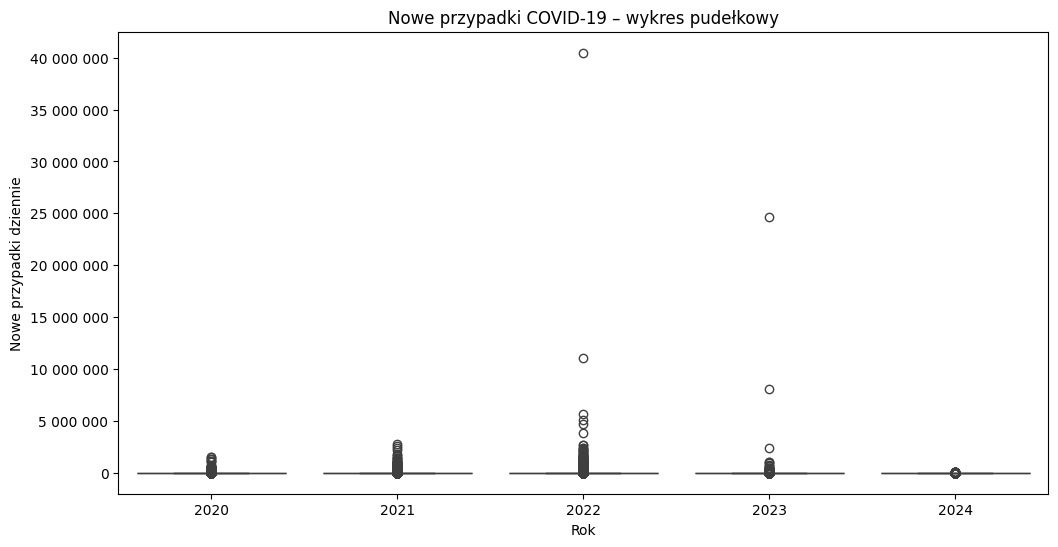

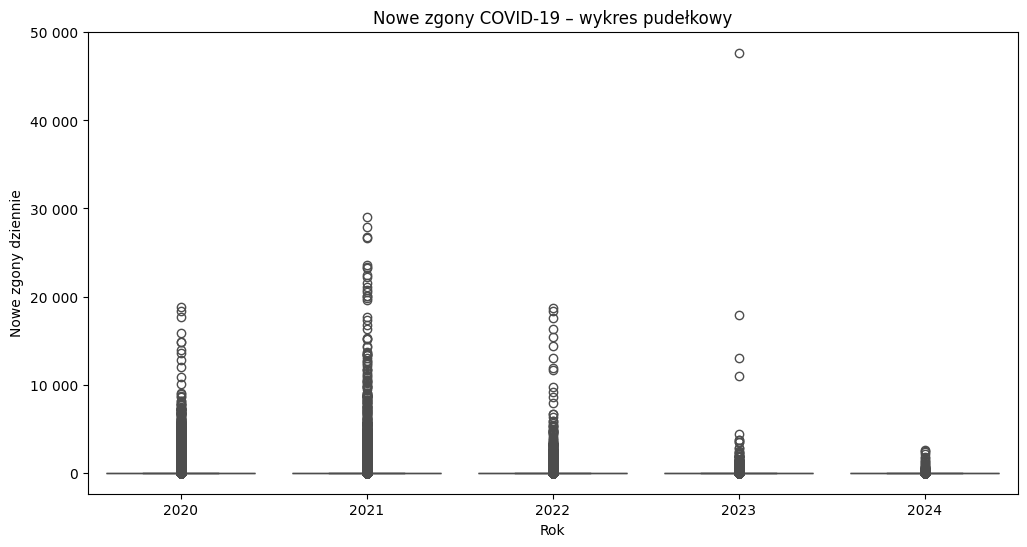

In [39]:
df['year'] = df['date'].dt.year
years = sorted(df['year'].unique())
formatter = FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' '))

#new_cases
plt.figure(figsize=(12, 6))
ax1 = sns.boxplot(x='year', y='new_cases', data=df)
ax1.yaxis.set_major_formatter(formatter)
plt.title("Nowe przypadki COVID-19 – wykres pudełkowy")
plt.xlabel("Rok")
plt.ylabel("Nowe przypadki dziennie")
plt.show()

#new_deaths
plt.figure(figsize=(12, 6))
ax2 = sns.boxplot(x='year', y='new_deaths', data=df, color='red')
ax2.yaxis.set_major_formatter(formatter)
plt.title("Nowe zgony COVID-19 – wykres pudełkowy")
plt.xlabel("Rok")
plt.ylabel("Nowe zgony dziennie")
plt.show()

Pierwszy wykres przedstawia rozkład dziennych zakażeń COVID-19 w podziale na lata. Widoczne są liczne wartości odstające, szczególnie w roku 2022, co wskazuje na gwałtowne skoki liczby nowych przypadków w niektórych dniach.

Drugi wykres ukazuje dzienną liczbę zgonów w kolejnych latach pandemii. Największe natężenie zgonów wystąpiło w latach 2021 i 2022, o czym świadczą wyższe mediany i więcej wartości odstających.

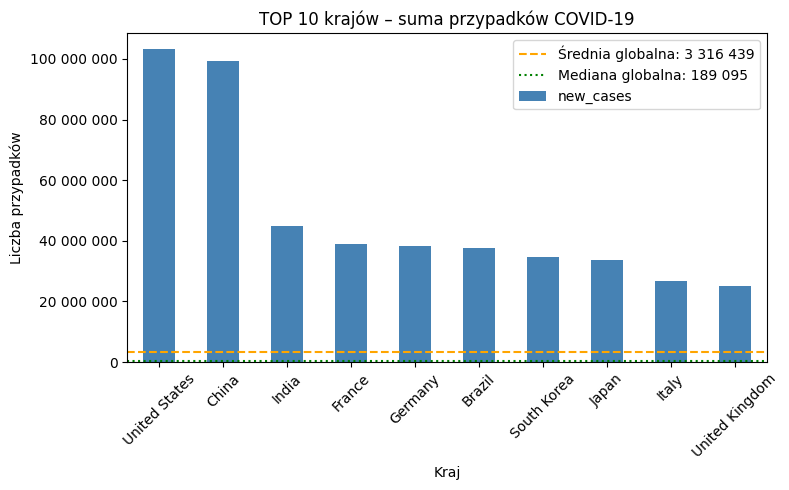

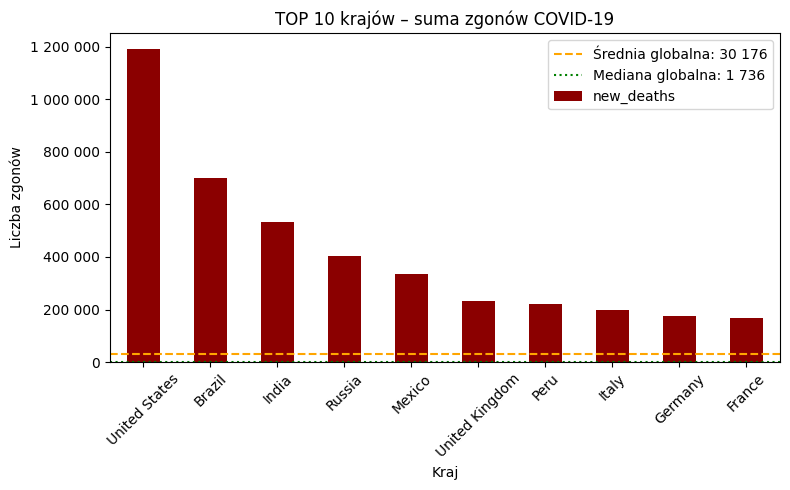

In [40]:
top_cases_by_country = df.groupby('location')['new_cases'].sum().sort_values(ascending=False).head(10)
all_cases_by_country = df.groupby('location')['new_cases'].sum()

mean_cases = all_cases_by_country.mean()
median_cases = all_cases_by_country.median()

plt.figure(figsize=(8, 5))
ax = top_cases_by_country.plot(kind='bar', color='steelblue')
plt.title("TOP 10 krajów – suma przypadków COVID-19")
plt.ylabel("Liczba przypadków")
plt.xlabel("Kraj")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(formatter)

plt.axhline(mean_cases, color='orange', linestyle='--', label=f'Średnia globalna: {int(mean_cases):,}'.replace(',', ' '))
plt.axhline(median_cases, color='green', linestyle=':', label=f'Mediana globalna: {int(median_cases):,}'.replace(',', ' '))

plt.legend()
plt.tight_layout()
plt.show()


top_deaths_by_country = df.groupby('location')['new_deaths'].sum().sort_values(ascending=False).head(10)
all_deaths_by_country = df.groupby('location')['new_deaths'].sum()

mean_deaths = all_deaths_by_country.mean()
median_deaths = all_deaths_by_country.median()

plt.figure(figsize=(8, 5))
ax = top_deaths_by_country.plot(kind='bar', color='darkred')
plt.title("TOP 10 krajów – suma zgonów COVID-19")
plt.ylabel("Liczba zgonów")
plt.xlabel("Kraj")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(formatter)

plt.axhline(mean_deaths, color='orange', linestyle='--', label=f'Średnia globalna: {int(mean_deaths):,}'.replace(',', ' '))
plt.axhline(median_deaths, color='green', linestyle=':', label=f'Mediana globalna: {int(median_deaths):,}'.replace(',', ' '))

plt.legend()
plt.tight_layout()
plt.show()

Pierwszy wykres przedstawia dziesięć krajów o najwyższej skumulowanej liczbie zakażeń COVID-19. Najwięcej przypadków odnotowano w Stanach Zjednoczonych i Chinach. Średnia i mediana globalna ukazują skalę dysproporcji względem reszty świata.

Drugi wykres pokazuje dziesięć krajów z najwyższą łączną liczbą zgonów. Stany Zjednoczone znacząco przewyższają pozostałe kraje, co podkreśla duże zróżnicowanie skutków pandemii na poziomie globalnym

In [453]:
df.to_csv('data/covid-data-cleaned.csv', index=False)

Ostateczna wersja przetworzonych danych została zapisana do pliku covid-data-cleaned.csv. Dalsza wizualizacja realizowana jest za pomocą narzędzia BI - Tableau. Wizualizacje z Tableau znajdują się w pliku covid-analysis-viz.twbx.